## Data Exploration

In [1]:
import pandas as pd
import sklearn
import scipy
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('csv_files/microsoft_stocks.csv')
df_c = df.copy()
df_c.head()

,Date,High,Low,Open,Close,Volume,Adj Close
0,2015-01-12,47.540001,46.360001,47.419998,46.599998,23651900.0,40.786396
1,2015-01-13,47.910000,46.060001,46.970001,46.360001,35270600.0,40.576340
2,2015-01-14,46.240002,45.619999,45.959999,45.959999,29719600.0,40.226257
3,2015-01-15,46.380001,45.410000,46.220001,45.480000,32750800.0,39.806129
4,2015-01-16,46.279999,45.169998,45.310001,46.240002,35695300.0,40.471313


In [3]:
df_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1925 entries, 0 to 1924
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1925 non-null   object 
 1   High       1925 non-null   float64
 2   Low        1925 non-null   float64
 3   Open       1925 non-null   float64
 4   Close      1925 non-null   float64
 5   Volume     1925 non-null   float64
 6   Adj Close  1925 non-null   float64
dtypes: float64(6), object(1)
memory usage: 105.4+ KB


In [4]:
for col in df_c.columns:
    if col != "Date":
        print(f"{col}:")
        print(f"Min {col} price: {df_c[col].min()}")
        print(f"Max {col} price: {df_c[col].max()}")
        print(f"Mean {col} price: {df_c[col].mean()}")
        print("-----")

High:
Min High price: 40.7400016784668
Max High price: 349.6700134277344
Mean High price: 140.3014545549665
-----
Low:
Min Low price: 39.720001220703125
Max Low price: 342.20001220703125
Mean Low price: 137.4829817457323
-----
Open:
Min Open price: 40.34000015258789
Max Open price: 344.6199951171875
Mean Open price: 138.93488833142567
-----
Close:
Min Close price: 40.290000915527344
Max Close price: 343.1099853515625
Mean Close price: 138.96709609192686
-----
Volume:
Min Volume price: 7425600.0
Max Volume price: 169164000.0
Mean Volume price: 30096868.987012986
-----
Adj Close:
Min Adj Close price: 35.35988998413086
Max Adj Close price: 340.8828125
Mean Adj Close price: 134.9475136496804
-----


In [5]:
df_c.isnull().sum()

Date         0
High         0
Low          0
Open         0
Close        0
Volume       0
Adj Close    0
dtype: int64

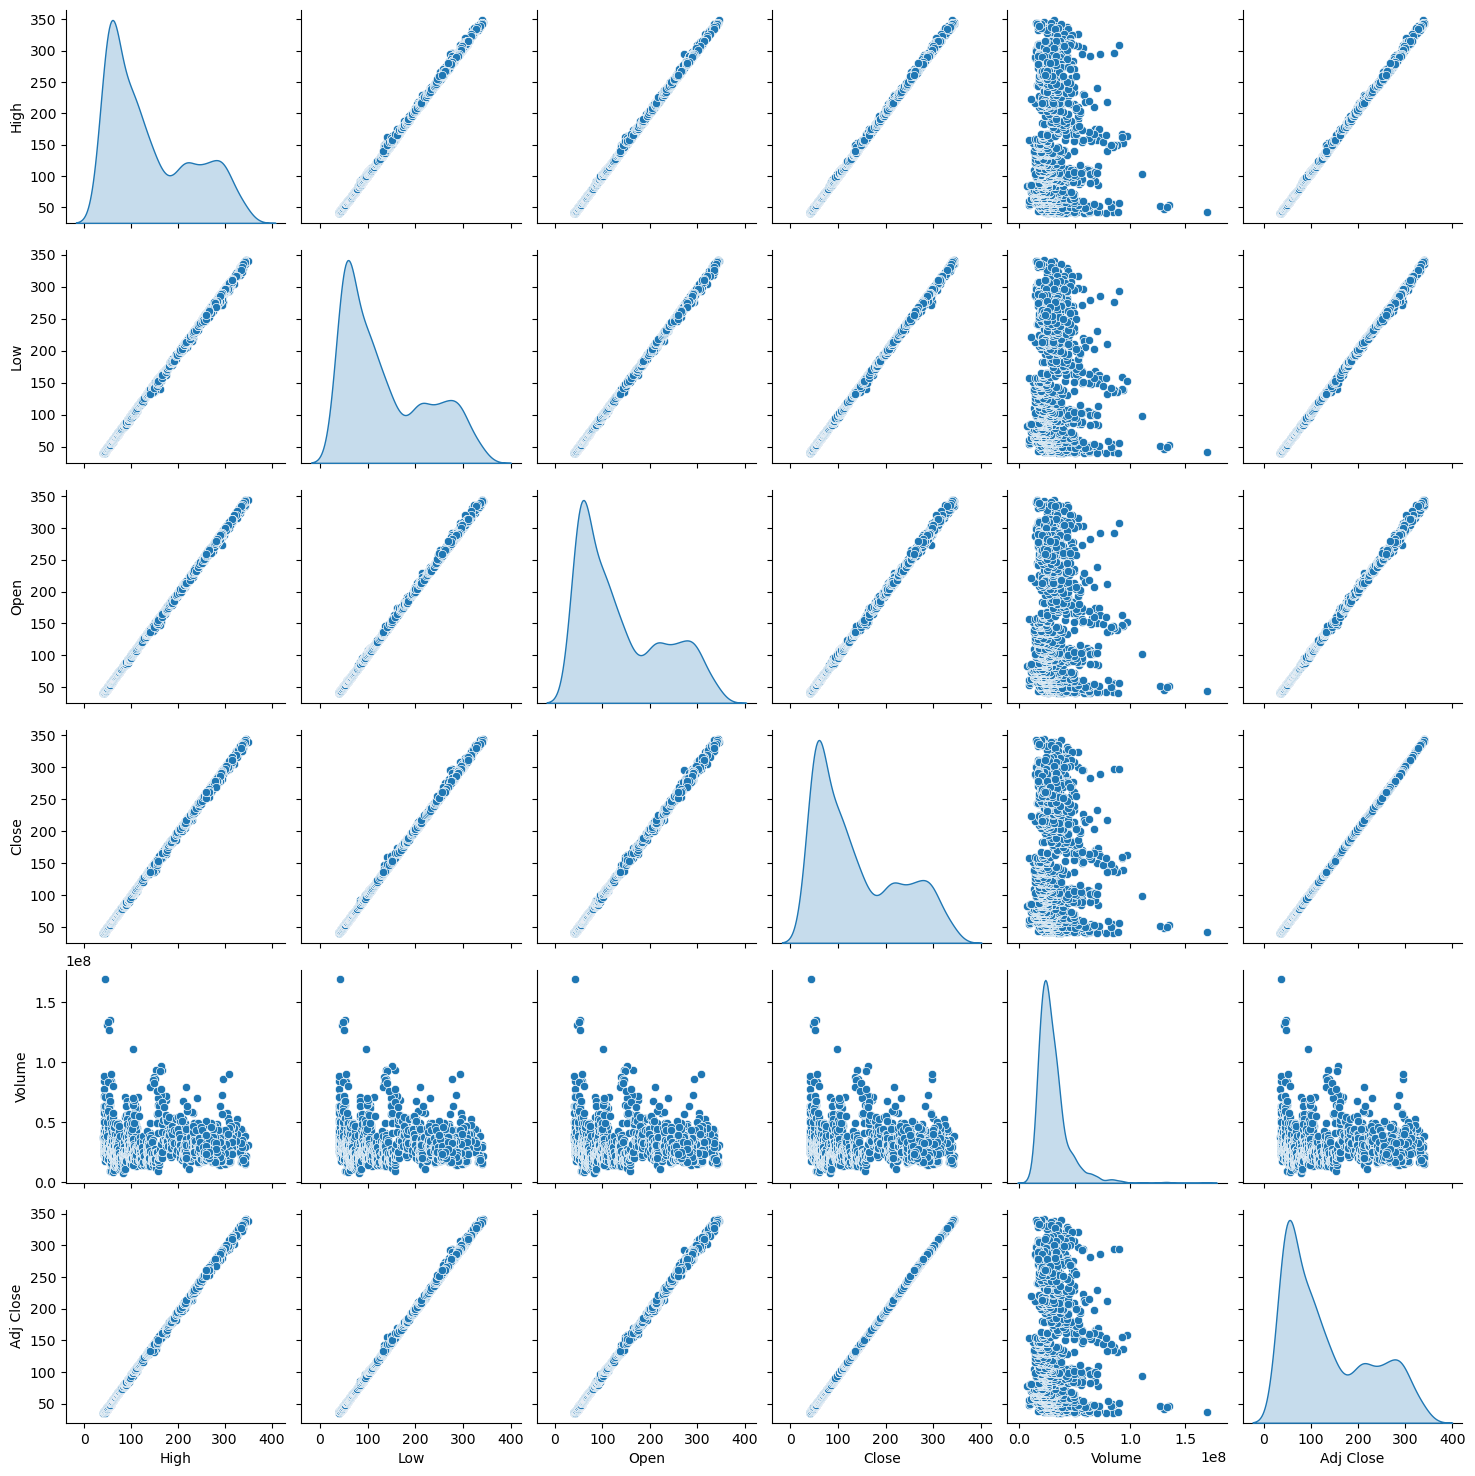

In [6]:
sns.pairplot(data=df_c,diag_kind='kde')

## Data Preparation

In [7]:
df_c['Date'] = pd.to_datetime(df_c['Date'])
df_c.set_index('Date',inplace=True)

In [8]:
X = df_c.drop(["Close" ,"Adj Close"],axis=1)
y= df_c['Close']

## Linear Regression Machine Learning:

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [10]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)
y_hat = model.predict(x_test)

In [11]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
mae = mean_absolute_error(y_test,y_hat)
mse = mean_squared_error(y_test,y_hat)
rmse = np.sqrt(mse)
mean_close = y_test.mean()
mae_percentage = (mae / mean_close) * 100
rmse_percentage = (rmse / mean_close) * 100
print(f"MAE:{mae}\nMSE:{mse}\nRMSE:{rmse}")
print(f"Mean Y test: {mean_close}")


MAE:0.6110577943096445
MSE:1.0842622878168413
RMSE:1.0412791594077169
Mean Y test: 140.5798444582929


In [12]:
print(f"MAE percentage: {mae_percentage}")
if mae_percentage < 1:
    print("Extremely good")
elif mae_percentage >=1 and mae_percentage < 3:
    print("Very good")
elif mae_percentage >=3 and mae_percentage < 5:
    print("Acceptable")
else:
    print("Bad")

print(f"RMSE percentage: {rmse_percentage}")
if rmse_percentage < 1:
    print("Extremely good")
elif rmse_percentage >=1 and rmse_percentage < 3:
    print("Very good")
elif rmse_percentage >=3 and rmse_percentage < 5:
    print("Acceptable")
else:
    print("Bad")

MAE percentage: 0.43466956210136687
Extremely good
RMSE percentage: 0.7407030242636543
Extremely good


In [13]:
residual = y_hat - y_test
res_df = pd.DataFrame({"Test": y_test, "Residual": residual})

<Axes: xlabel='Test', ylabel='Residual'>

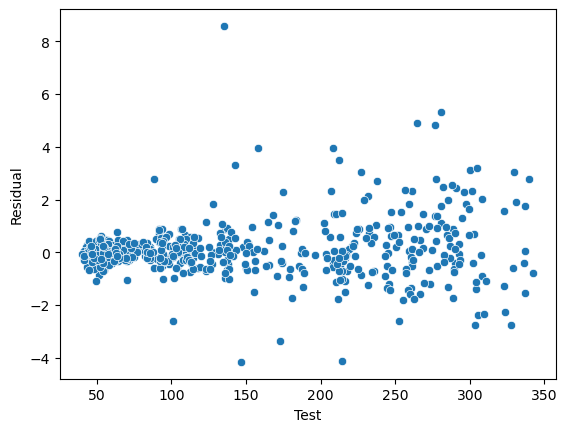

In [14]:
sns.scatterplot(x='Test',y="Residual",data=res_df)

## Model Deployment: